In [14]:
'''
“Linear Regression from Scratch” - Purpose: the first project where you
build the algorithm, not just the pipeline around it — this is what makes gradient
descent click permanently instead of staying an abstract diagram. - Spec:
numpy only, no scikit-learn. Generate or download a small single-feature or
two-feature dataset (e.g., a simple synthetic linear relationship with noise, or a
small real dataset like height-vs-weight). - Deliverables: implement the cost
function (MSE), the gradient computation, and the update loop by hand; plot
the cost decreasing over iterations to confirm convergence; plot your fitted line
against the data; compare your learned coefficients against np.linalg.lstsq
or scikit-learn’s LinearRegression on the same data and report how close they
are. - Stretch goal: implement logistic regression from scratch the same way
(sigmoid + binary cross-entropy loss instead of MSE) on a small 2-class synthetic
dataset — this directly previews Project 1’s core model family.
'''

'\n“Linear Regression from Scratch” - Purpose: the first project where you\nbuild the algorithm, not just the pipeline around it — this is what makes gradient\ndescent click permanently instead of staying an abstract diagram. - Spec:\nnumpy only, no scikit-learn. Generate or download a small single-feature or\ntwo-feature dataset (e.g., a simple synthetic linear relationship with noise, or a\nsmall real dataset like height-vs-weight). - Deliverables: implement the cost\nfunction (MSE), the gradient computation, and the update loop by hand; plot\nthe cost decreasing over iterations to confirm convergence; plot your fitted line\nagainst the data; compare your learned coefficients against np.linalg.lstsq\nor scikit-learn’s LinearRegression on the same data and report how close they\nare. - Stretch goal: implement logistic regression from scratch the same way\n(sigmoid + binary cross-entropy loss instead of MSE) on a small 2-class synthetic\ndataset — this directly previews Project 1’s cor

In [15]:
import numpy as np
import pandas as pd

In [16]:
df = pd.read_csv("https://raw.githubusercontent.com/Avik-Jain/100-Days-Of-ML-Code/master/datasets/Social_Network_Ads.csv")
df.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [17]:
x_train = df['Age'].to_numpy()
x_train

array([19, 35, 26, 27, 19, 27, 27, 32, 25, 35, 26, 26, 20, 32, 18, 29, 47,
       45, 46, 48, 45, 47, 48, 45, 46, 47, 49, 47, 29, 31, 31, 27, 21, 28,
       27, 35, 33, 30, 26, 27, 27, 33, 35, 30, 28, 23, 25, 27, 30, 31, 24,
       18, 29, 35, 27, 24, 23, 28, 22, 32, 27, 25, 23, 32, 59, 24, 24, 23,
       22, 31, 25, 24, 20, 33, 32, 34, 18, 22, 28, 26, 30, 39, 20, 35, 30,
       31, 24, 28, 26, 35, 22, 30, 26, 29, 29, 35, 35, 28, 35, 28, 27, 28,
       32, 33, 19, 21, 26, 27, 26, 38, 39, 37, 38, 37, 42, 40, 35, 36, 40,
       41, 36, 37, 40, 35, 41, 39, 42, 26, 30, 26, 31, 33, 30, 21, 28, 23,
       20, 30, 28, 19, 19, 18, 35, 30, 34, 24, 27, 41, 29, 20, 26, 41, 31,
       36, 40, 31, 46, 29, 26, 32, 32, 25, 37, 35, 33, 18, 22, 35, 29, 29,
       21, 34, 26, 34, 34, 23, 35, 25, 24, 31, 26, 31, 32, 33, 33, 31, 20,
       33, 35, 28, 24, 19, 29, 19, 28, 34, 30, 20, 26, 35, 35, 49, 39, 41,
       58, 47, 55, 52, 40, 46, 48, 52, 59, 35, 47, 60, 49, 40, 46, 59, 41,
       35, 37, 60, 35, 37

In [18]:
y_train = df['Purchased'].to_numpy()
y_train

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,

In [19]:
def sigmoid(z):
    g = 1/(1+np.exp(-z))
    return g

In [20]:
def cost_func(x,y,w,b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(x[i], w) + b
        f_wb = sigmoid(z_i)
        cost += -y[i]*np.log(f_wb) - (1-y[i])*np.log(1-f_wb)

    cost = cost / m
    return cost


In [21]:
def compute_gradient(X,y,w,b):
    m,n = X.shape
    dj_dw = np.zeros((n,))                           
    dj_db = 0.

    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)          
        err_i  = f_wb_i  - y[i]                       
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err_i * X[i,j]      
        dj_db = dj_db + err_i
    dj_dw = dj_dw/m                                   
    dj_db = dj_db/m                                  
        
    return dj_db, dj_dw  

In [22]:
import copy, math

def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_db, dj_dw = compute_gradient(X, y, w, b)   
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 100000:
            J_history.append(cost_func(X, y, w, b) )

        if i% math.ceil(num_iters / 10) == 0:
             print(f"Iteration {i:4d}: Cost {J_history[-1]}   ")

    return w, b, J_history





In [28]:
x_train = x_train.reshape(-1, 1)

w_tmp  = np.zeros(x_train.shape[1])
b_tmp  = 0.
alph = 0.01
iters = 10000

w_out, b_out, j_hist = gradient_descent(x_train, y_train, w_tmp, b_tmp, alph, iters) 
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.7352752621163817   
Iteration 1000: Cost 1.8017678576695904   
Iteration 2000: Cost 1.7187597160147363   
Iteration 3000: Cost 1.629581862031416   
Iteration 4000: Cost 1.5366790292793018   
Iteration 5000: Cost 1.4422855867502502   
Iteration 6000: Cost 1.3485094960581654   
Iteration 7000: Cost 1.257373213075126   
Iteration 8000: Cost 1.1707476468205522   
Iteration 9000: Cost 1.0901670434391755   

updated parameters: w:[0.21891418], b:-6.09325938242806


In [29]:
x_train = (x_train - np.mean(x_train)) / np.std(x_train)

w_tmp = np.zeros(x_train.shape[1])
b_tmp = 0.0
alph = 0.1
iters = 1000

w_out, b_out, J_hist = gradient_descent(x_train, y_train, w_tmp, b_tmp, alph, iters)
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.6823537012347907   
Iteration  100: Cost 0.4406415379259743   
Iteration  200: Cost 0.42459393106330906   
Iteration  300: Cost 0.42146614734526894   
Iteration  400: Cost 0.42066182298112886   
Iteration  500: Cost 0.4204299292854205   
Iteration  600: Cost 0.42035924269481234   
Iteration  700: Cost 0.42033705664354826   
Iteration  800: Cost 0.42032998139709493   
Iteration  900: Cost 0.4203277049858254   

updated parameters: w:[1.97498257], b:-0.9278179491853965


C:\Users\emman\AppData\Local\Temp\ipykernel_28272\2686428463.py:29: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Brady Bunch.
  plt.tight_layout()
C:\Users\emman\miniconda3\envs\ml_env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Brady Bunch.
  fig.canvas.print_figure(bytes_io, **kw)


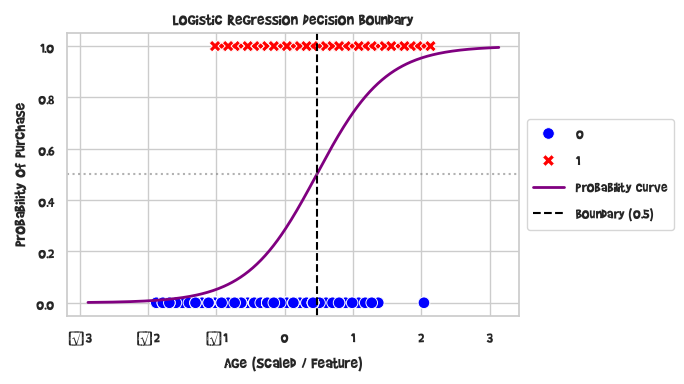

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plot = pd.DataFrame({
    'Feature': x_train.flatten(),
    'Purchased': y_train
})
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))

sns.scatterplot(data=plot, x='Feature', y='Purchased', hue='Purchased', 
                palette={0: 'blue', 1: 'red'}, style='Purchased', s=70)

x_range = np.linspace(plot['Feature'].min() - 1, plot['Feature'].max() + 1, 300)
z = w_out[0] * x_range + b_out
prob = 1 / (1 + np.exp(-z))

sns.lineplot(x=x_range, y=prob, color='purple', label='Probability Curve', linewidth=2)

if w_out[0] != 0:
    x_db = -b_out / w_out[0]
    plt.axvline(x=x_db, color='black', linestyle='--', label=f'Boundary ({x_db:.1f})')
    plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.6)

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Age (Scaled / Feature)")
plt.ylabel("Probability of Purchase")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
